In [2]:
import sys
print(sys.executable)

d:\ChurnGuard Ai\.venv\Scripts\python.exe


In [3]:
import sys
print(sys.executable)

d:\ChurnGuard Ai\.venv\Scripts\python.exe


In [4]:
import pandas as pd

In [5]:
import pandas as pd

# Load the raw Telco dataset
df = pd.read_csv("../data/Churn_data.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [6]:
import os
print("Current working directory:", os.getcwd())
print("\nFiles in current directory:", os.listdir())

Current working directory: d:\ChurnGuard Ai\src

Files in current directory: ['data_prep_01.ipynb']


In [7]:
import os
print("Current working directory:", os.getcwd())
print("\nFiles in current directory:", os.listdir())

Current working directory: d:\ChurnGuard Ai\src

Files in current directory: ['data_prep_01.ipynb']


In [8]:
print("One level up:", os.listdir(".."))

One level up: ['.venv', 'data', 'src']


In [9]:
print("Files in data folder:", os.listdir("../data"))

Files in data folder: ['churnguard_features.csv', 'churnguard_prepared.csv', 'Churn_data.csv']


In [10]:
import pandas as pd

# Load the raw Telco dataset
df = pd.read_csv("../data/Churn_data.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [11]:
# Find rows where TotalCharges isn't a clean number
bad_rows = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
print("Number of bad rows:", len(bad_rows))
bad_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Number of bad rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [12]:
# Convert TotalCharges to numeric — blanks (tenure=0 customers) become NaN first
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill those NaNs with 0 (they're new customers with $0 billed so far)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify the fix
print("TotalCharges dtype now:", df["TotalCharges"].dtype)
print("Any missing values left?", df["TotalCharges"].isna().sum())

TotalCharges dtype now: float64
Any missing values left? 0


In [13]:
df = df.rename(columns={
    "Contract": "subscription_plan",
    "MonthlyCharges": "monthly_spend",
    "tenure": "customer_tenure_months",
    "Churn": "will_churn"
})

# Confirm the rename worked
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'customer_tenure_months', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'subscription_plan', 'PaperlessBilling', 'PaymentMethod', 'monthly_spend', 'TotalCharges', 'will_churn']


In [14]:
import numpy as np

np.random.seed(42)  # so results are reproducible every time you rerun this

# Higher average tickets for churners (moderate signal)
churn_mask = df["will_churn"] == "Yes"

support_tickets = np.zeros(len(df), dtype=int)
support_tickets[churn_mask] = np.random.poisson(lam=2.0, size=churn_mask.sum())
support_tickets[~churn_mask] = np.random.poisson(lam=0.8, size=(~churn_mask).sum())

# Cap at 5 per the spec (0-5 range)
support_tickets = np.clip(support_tickets, 0, 5)

df["support_tickets_last_90d"] = support_tickets

# Quick sanity check: average tickets by churn status
print(df.groupby("will_churn")["support_tickets_last_90d"].mean())

will_churn
No     0.788365
Yes    1.981808
Name: support_tickets_last_90d, dtype: float64


In [15]:
feature_usage = np.zeros(len(df))
feature_usage[churn_mask] = np.random.normal(loc=35, scale=15, size=churn_mask.sum())
feature_usage[~churn_mask] = np.random.normal(loc=60, scale=15, size=(~churn_mask).sum())

# Clip to valid 0-100 range (normal distribution can technically go outside it)
feature_usage = np.clip(feature_usage, 0, 100)

df["feature_usage_score"] = feature_usage

# Sanity check
print(df.groupby("will_churn")["feature_usage_score"].mean())

will_churn
No     60.318682
Yes    35.282961
Name: feature_usage_score, dtype: float64


In [16]:
days_since_login = np.zeros(len(df))
days_since_login[churn_mask] = np.random.normal(loc=25, scale=12, size=churn_mask.sum())
days_since_login[~churn_mask] = np.random.normal(loc=8, scale=6, size=(~churn_mask).sum())

# Can't have negative days — clip at 0, no real upper bound needed but let's cap at something sane
days_since_login = np.clip(days_since_login, 0, 90)

df["days_since_last_login"] = days_since_login.round().astype(int)

# Sanity check
print(df.groupby("will_churn")["days_since_last_login"].mean())

will_churn
No      8.190955
Yes    24.967897
Name: days_since_last_login, dtype: float64


In [17]:
df[["will_churn", "support_tickets_last_90d", "feature_usage_score", "days_since_last_login"]].groupby("will_churn").mean()

,support_tickets_last_90d,feature_usage_score,days_since_last_login
will_churn,,,
No,0.788365,60.318682,8.190955
Yes,1.981808,35.282961,24.967897


In [18]:
# Save the prepared dataset for use in later steps (EDA, feature engineering, etc.)
df.to_csv("../data/churnguard_prepared.csv", index=False)
print("Saved. Final shape:", df.shape)

Saved. Final shape: (7043, 24)


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the prepared dataset fresh
df = pd.read_csv("../data/churnguard_prepared.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,customer_tenure_months,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,subscription_plan,PaperlessBilling,PaymentMethod,monthly_spend,TotalCharges,will_churn,support_tickets_last_90d,feature_usage_score,days_since_last_login
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,67.458270,6
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,32.405432,20
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,51.895902,24
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1,41.026667,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,33.520874,18


will_churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


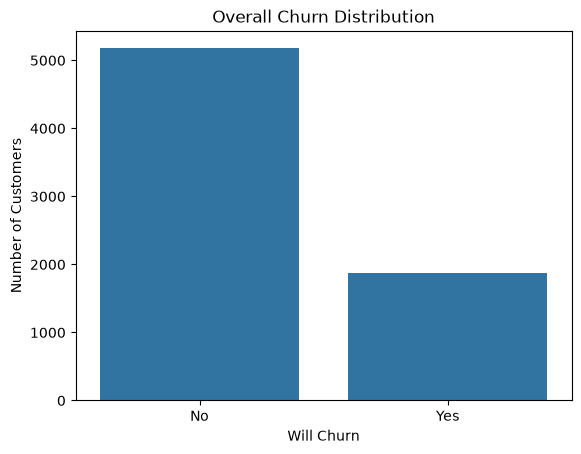

In [20]:
churn_rate = df["will_churn"].value_counts(normalize=True) * 100
print(churn_rate)

# Visualize it
sns.countplot(data=df, x="will_churn")
plt.title("Overall Churn Distribution")
plt.xlabel("Will Churn")
plt.ylabel("Number of Customers")
plt.show()

will_churn                No        Yes
subscription_plan                      
Month-to-month     57.290323  42.709677
One year           88.730482  11.269518
Two year           97.168142   2.831858


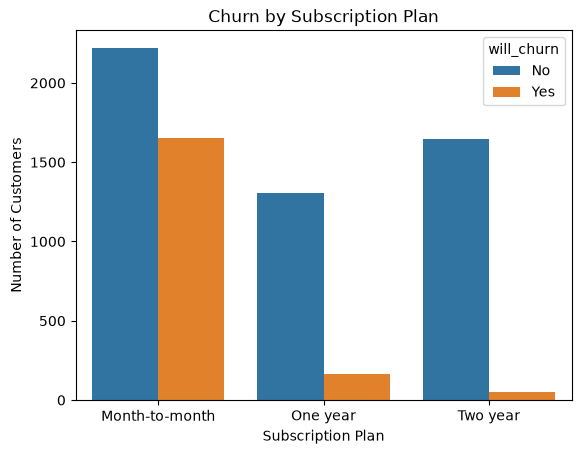

In [21]:
plan_churn = df.groupby("subscription_plan")["will_churn"].value_counts(normalize=True).unstack() * 100
print(plan_churn)

# Visualize
sns.countplot(data=df, x="subscription_plan", hue="will_churn")
plt.title("Churn by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Number of Customers")
plt.show()

will_churn
No     37.569965
Yes    17.979133
Name: customer_tenure_months, dtype: float64


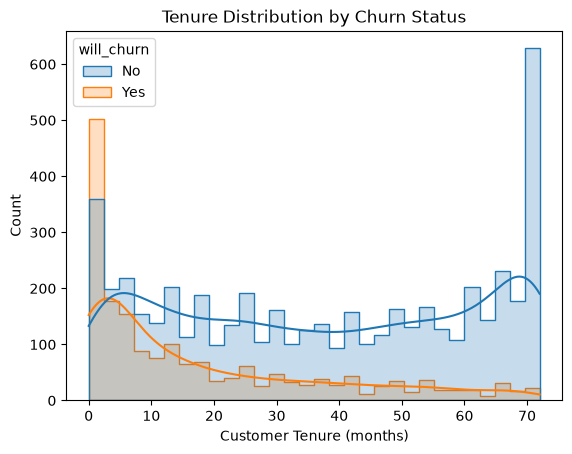

In [22]:
# Compare average tenure between churners and non-churners
print(df.groupby("will_churn")["customer_tenure_months"].mean())

# Visualize distribution
sns.histplot(data=df, x="customer_tenure_months", hue="will_churn", bins=30, kde=True, element="step")
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Customer Tenure (months)")
plt.ylabel("Count")
plt.show()

will_churn
No     61.265124
Yes    74.441332
Name: monthly_spend, dtype: float64


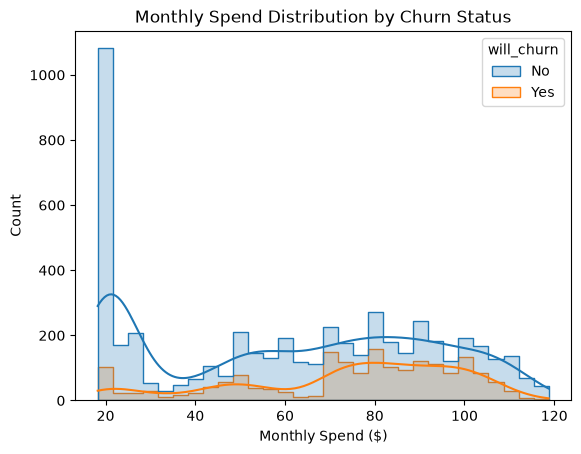

In [23]:
print(df.groupby("will_churn")["monthly_spend"].mean())

sns.histplot(data=df, x="monthly_spend", hue="will_churn", bins=30, kde=True, element="step")
plt.title("Monthly Spend Distribution by Churn Status")
plt.xlabel("Monthly Spend ($)")
plt.ylabel("Count")
plt.show()

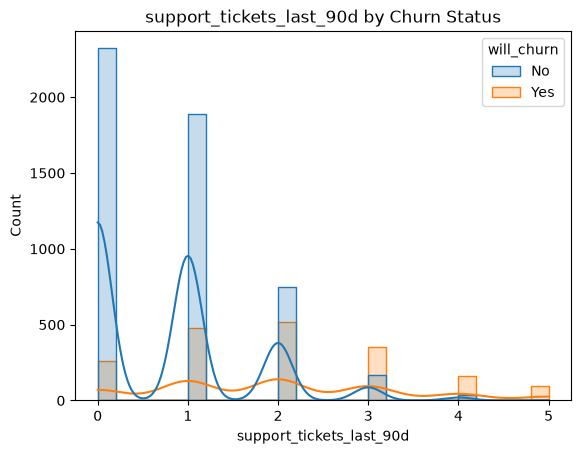

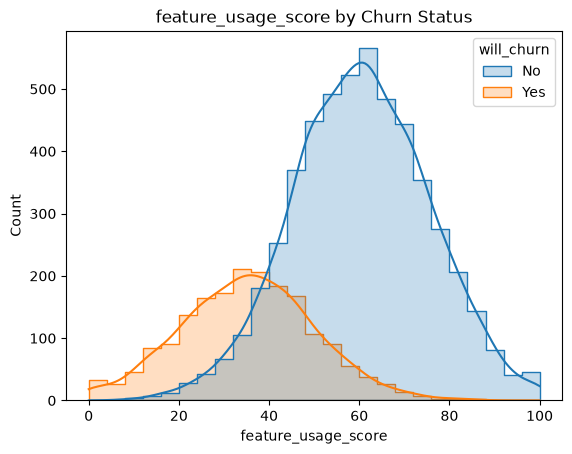

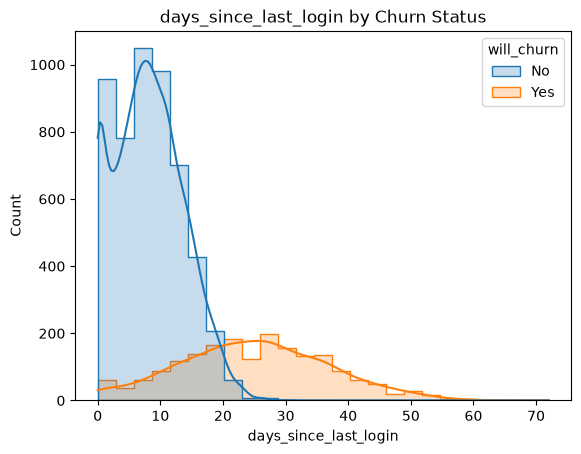

In [24]:
engagement_cols = ["support_tickets_last_90d", "feature_usage_score", "days_since_last_login"]

for col in engagement_cols:
    fig, ax = plt.subplots()
    sns.histplot(data=df, x=col, hue="will_churn", bins=25, kde=True, element="step", ax=ax)
    ax.set_title(f"{col} by Churn Status")
    plt.show()

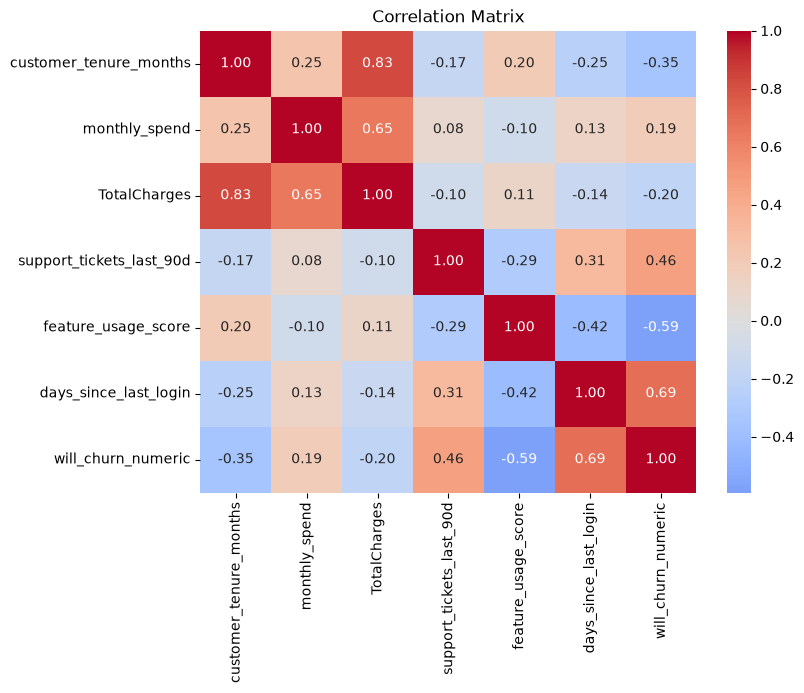

will_churn_numeric          1.000000
days_since_last_login       0.693345
support_tickets_last_90d    0.459051
monthly_spend               0.193356
TotalCharges               -0.198324
customer_tenure_months     -0.352229
feature_usage_score        -0.593076
Name: will_churn_numeric, dtype: float64


In [25]:
# Convert will_churn to numeric temporarily for correlation purposes
df["will_churn_numeric"] = (df["will_churn"] == "Yes").astype(int)

numeric_cols = ["customer_tenure_months", "monthly_spend", "TotalCharges",
                 "support_tickets_last_90d", "feature_usage_score", 
                 "days_since_last_login", "will_churn_numeric"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Just the correlations with churn, sorted
print(corr_matrix["will_churn_numeric"].sort_values(ascending=False))

In [26]:
df = df.drop(columns=["TotalCharges"])
print("Remaining columns:", df.shape[1])
print(df.columns.tolist())

Remaining columns: 24
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'customer_tenure_months', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'subscription_plan', 'PaperlessBilling', 'PaymentMethod', 'monthly_spend', 'will_churn', 'support_tickets_last_90d', 'feature_usage_score', 'days_since_last_login', 'will_churn_numeric']


In [27]:
df = df.drop(columns=["will_churn_numeric"])
print("Remaining columns:", df.shape[1])

Remaining columns: 23


In [28]:
# subscription_plan has real order: Month-to-month < One year < Two year
plan_order = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df["subscription_plan_encoded"] = df["subscription_plan"].map(plan_order)

# Sanity check
print(df[["subscription_plan", "subscription_plan_encoded"]].drop_duplicates())

   subscription_plan  subscription_plan_encoded
0     Month-to-month                          0
1           One year                          1
11          Two year                          2


In [29]:
df = df.drop(columns=["customerID"])
print("Columns after dropping customerID:", df.shape[1])

Columns after dropping customerID: 23


In [30]:
categorical_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
                     "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                     "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling",
                     "PaymentMethod"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after one-hot encoding:", df.shape)
df.head()

Shape after one-hot encoding: (7043, 33)


,SeniorCitizen,customer_tenure_months,subscription_plan,monthly_spend,will_churn,support_tickets_last_90d,feature_usage_score,days_since_last_login,subscription_plan_encoded,gender_Male,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,Month-to-month,29.85,No,0,67.458270,6,0,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,One year,56.95,No,0,32.405432,20,1,True,...,False,False,False,False,False,False,False,False,False,True
2,0,2,Month-to-month,53.85,Yes,4,51.895902,24,0,True,...,False,False,False,False,False,False,True,False,False,True
3,0,45,One year,42.30,No,1,41.026667,1,1,True,...,False,True,False,False,False,False,False,False,False,False
4,0,2,Month-to-month,70.70,Yes,1,33.520874,18,0,False,...,False,False,False,False,False,False,True,False,True,False


In [31]:
df = df.drop(columns=["subscription_plan"])
print("Shape after cleanup:", df.shape)

Shape after cleanup: (7043, 32)


In [32]:
# Top 25% by monthly spend = high value
spend_threshold = df["monthly_spend"].quantile(0.75)
print("75th percentile spend threshold:", spend_threshold)

df["is_high_value_customer"] = (df["monthly_spend"] >= spend_threshold).astype(int)

# Sanity check
print(df["is_high_value_customer"].value_counts())
print("\nChurn rate by high-value status:")
print(df.groupby("is_high_value_customer")["will_churn"].value_counts(normalize=True).unstack())

75th percentile spend threshold: 89.85
is_high_value_customer
0    5272
1    1771
Name: count, dtype: int64

Churn rate by high-value status:
will_churn                    No       Yes
is_high_value_customer                    
0                       0.755501  0.244499
1                       0.672501  0.327499


In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize each engagement field to 0-1
normalized = scaler.fit_transform(df[["support_tickets_last_90d", "feature_usage_score", "days_since_last_login"]])
df["support_tickets_norm"] = normalized[:, 0]
df["feature_usage_norm"] = normalized[:, 1]
df["days_since_login_norm"] = normalized[:, 2]

# Flip the "bad" signals so higher = healthier engagement
# (more tickets = worse, more days since login = worse, so we invert them)
df["support_tickets_norm_inv"] = 1 - df["support_tickets_norm"]
df["days_since_login_norm_inv"] = 1 - df["days_since_login_norm"]

# feature_usage_norm is already "higher = better", no need to invert

# Combine into single engagement_trend score (equal weight average)
df["engagement_trend"] = (df["support_tickets_norm_inv"] + df["feature_usage_norm"] + df["days_since_login_norm_inv"]) / 3

# Sanity check
print(df.groupby("will_churn")["engagement_trend"].mean())

will_churn
No     0.777250
Yes    0.536564
Name: engagement_trend, dtype: float64


In [34]:
df = df.drop(columns=["support_tickets_norm", "feature_usage_norm", "days_since_login_norm",
                       "support_tickets_norm_inv", "days_since_login_norm_inv"])
print("Shape after cleanup:", df.shape)

Shape after cleanup: (7043, 34)


In [35]:
def tenure_segment(months):
    if months <= 6:
        return "New"
    elif months <= 24:
        return "Established"
    else:
        return "Loyal"

df["tenure_segment"] = df["customer_tenure_months"].apply(tenure_segment)

# Sanity check
print(df["tenure_segment"].value_counts())
print("\nChurn rate by tenure segment:")
print(df.groupby("tenure_segment")["will_churn"].value_counts(normalize=True).unstack())

tenure_segment
Loyal          3833
Established    1729
New            1481
Name: count, dtype: int64

Churn rate by tenure segment:
will_churn            No       Yes
tenure_segment                    
Established     0.683632  0.316368
Loyal           0.859640  0.140360
New             0.470628  0.529372


In [36]:
def spend_segment(spend):
    if spend < 35:
        return "Low"
    elif spend <= 89.85:
        return "Medium"
    else:
        return "High"

df["spend_segment"] = df["monthly_spend"].apply(spend_segment)

# Sanity check
print(df["spend_segment"].value_counts())
print("\nChurn rate by spend segment:")
print(df.groupby("spend_segment")["will_churn"].value_counts(normalize=True).unstack())

spend_segment
Medium    3554
High      1758
Low       1731
Name: count, dtype: int64

Churn rate by spend segment:
will_churn           No       Yes
spend_segment                    
High           0.671217  0.328783
Low            0.891392  0.108608
Medium         0.689645  0.310355


In [37]:
print("Final shape:", df.shape)
print("\nColumn list:")
print(df.columns.tolist())

Final shape: (7043, 36)

Column list:
['SeniorCitizen', 'customer_tenure_months', 'monthly_spend', 'will_churn', 'support_tickets_last_90d', 'feature_usage_score', 'days_since_last_login', 'subscription_plan_encoded', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'is_high_value_customer', 'engagement_trend', 'tenure_segment', 'spend_segment']


In [38]:
df.to_csv("../data/churnguard_features.csv", index=False)
print("Saved churnguard_features.csv")

Saved churnguard_features.csv


In [39]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop(columns=["will_churn", "tenure_segment", "spend_segment"])
y = df["will_churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (5634, 33)
Test shape: (1409, 33)

Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

print("Class weights (0=No churn, 1=Yes churn):", class_weights)

Class weights (0=No churn, 1=Yes churn): [0.68059918 1.88428094]


In [41]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train churn rate:", y_train.mean())
print("y_test churn rate:", y_test.mean())
print("\nComputed class weights:", dict(zip([0, 1], class_weights)))

X_train shape: (5634, 33)
X_test shape: (1409, 33)
y_train churn rate: 0.2653532126375577
y_test churn rate: 0.2654364797728886

Computed class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

    No Churn       0.97      0.93      0.95      1035
       Churn       0.83      0.93      0.88       374

    accuracy                           0.93      1409
   macro avg       0.90      0.93      0.91      1409
weighted avg       0.93      0.93      0.93      1409

ROC-AUC: 0.9810586685266993


In [43]:
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

print("Train/test data saved")

Train/test data saved
